In [82]:
from aPythonPack import * #pip install git+https://github.com/sebPV/aPythonPack.git
import aPythonPack.LatexConversions as lc
import scipy as sc
import pandas as pd
import os

# Data imoprt

In [51]:
fors = []
# pd.read_csv("Data/20260324-090928_Wheel.csv")
# for i in os.listdir('Data'):
for i in os.listdir('Data'):
    fors.append({'data':pd.read_csv("Data/"+i)})



# Data[' time']

In [52]:
fors

[{'data':     index   frame   sample   time   raw[0]    cal[0]   raw[1]    cal[1]  \
  0       0      10        0   0.01        4  0.007333        4  0.366667   
  1       1      11        0   0.02        7  0.009250        3  0.375000   
  2       2      12        0   0.03       11  0.011000        4  0.360000   
  3       3      13        0   0.04       15  0.014600        4  0.360000   
  4       4      14        0   0.05       18  0.018400        3  0.380000   
  ..    ...     ...      ...    ...      ...       ...      ...       ...   
  83     83      93        0   0.84      542  0.541800       10  0.940000   
  84     84      94        0   0.85      551  0.551200        9  0.940000   
  85     85      95        0   0.86      561  0.560000       10  0.880000   
  86     86      96        0   0.87      570  0.564500        9  0.850000   
  87     87      97        0   0.88      576  0.569000        6  0.833333   
  
       raw[2]    cal[2]  
  0         4  0.277778  
  1        -1

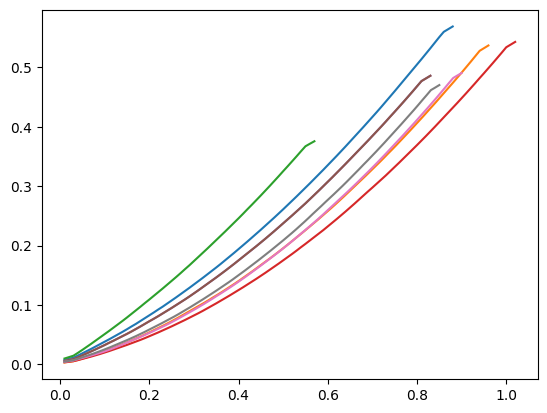

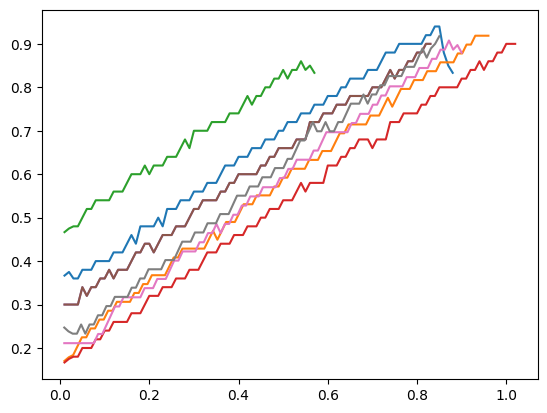

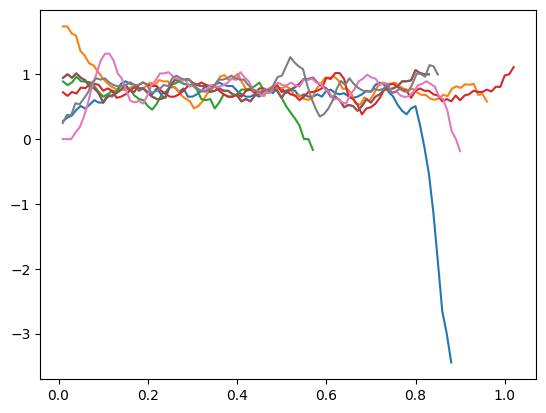

In [53]:
for i in range(3):
    for j in fors:
        plt.plot(j['data'][' time'],j['data'][' cal['+str(i)+']'])
    plt.show()

In [76]:
PI1,PI2 = [],[]

for i in fors:
    t = i['data'][' time'][len(i['data'][' time'])-1]
    s = i['data'][' cal[0]'][len(i['data'][' time'])-1]
    v = i['data'][' cal[1]'][0]
    a = np.average(i['data'][' cal[2]'])
    i['PI1'] = s/(v*t)
    i['PI2'] = t * a/(v)
    PI1.append(i['PI1'])
    PI2.append(i['PI2'])


In [65]:
def f(x,a,b):
    return a*x +b

[ 2.08526919 -2.11231257]


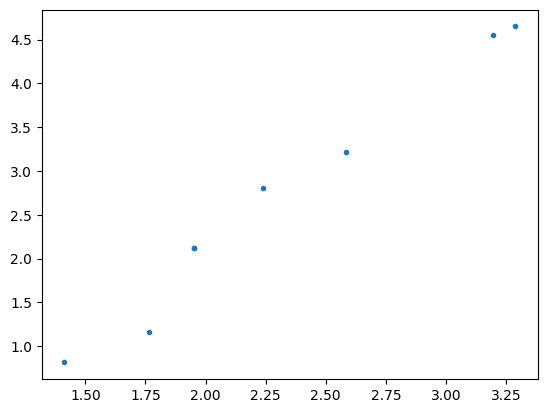

In [87]:
from scipy.optimize import curve_fit
param,cov = curve_fit(f,PI1,PI2)
print(param)
plt.plot(PI1,PI2,'.')
    # plt.show()

In [99]:
plot = lc.tikzPlot()
plot.addPlot(PI1,PI2,legend='Data',line='o')
plot.addPlot(PI1,f(np.array(PI1),param[0],param[1]),legend='$\\Pi_1 \\cdot'+ str(round(param[0],3))+str(round(param[1],3))+'$',line='--')
# plot.printPlot()
plot.writePLot('plots/piplot')